In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
import cv2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')


# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("TensorFlow Version:", tf.__version__)

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow Version: 2.19.0


In [8]:
# Mount Google Drive and extract dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import zipfile
import os

dataset_path = '/content/drive/MyDrive/andleeb_dl_ass/DL_Assignment1_Dataset.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [10]:
class ImprovedAffectNetDataLoader:
    """
    Enhanced class to load and preprocess AffectNet dataset with better error handling and data validation
    """

    def __init__(self, base_path, max_samples=None):
        self.base_path = base_path
        self.annotations_path = os.path.join(base_path, 'Dataset', 'Dataset', 'annotations')
        self.images_path = os.path.join(base_path, 'Dataset', 'Dataset', 'images')
        self.max_samples = max_samples
        self.expression_labels = {
            0: 'Neutral', 1: 'Happy', 2: 'Sad', 3: 'Surprise',
            4: 'Fear', 5: 'Disgust', 6: 'Anger', 7: 'Contempt'
        }

    def load_annotations(self):
        """Load all annotation files with better error handling and validation"""
        print("Loading annotations...")

        try:
            annotation_files = os.listdir(self.annotations_path)
            file_ids = set()

            for file in annotation_files:
                if file.endswith('.npy'):
                    try:
                        id_part = file.split('_')[0]
                        if id_part.isdigit():
                            file_ids.add(int(id_part))
                    except (ValueError, IndexError):
                        continue

            file_ids = sorted(list(file_ids))
            print(f"Found {len(file_ids)} unique samples")

            if self.max_samples:
                file_ids = file_ids[:self.max_samples]
                print(f"Limiting to {self.max_samples} samples for demonstration")

            data = []
            valid_ids = []
            error_count = 0

            for file_id in file_ids:
                try:
                    aro_path = os.path.join(self.annotations_path, f"{file_id}_aro.npy")
                    exp_path = os.path.join(self.annotations_path, f"{file_id}_exp.npy")
                    val_path = os.path.join(self.annotations_path, f"{file_id}_val.npy")
                    lnd_path = os.path.join(self.annotations_path, f"{file_id}_lnd.npy")

                    if all(os.path.exists(path) for path in [aro_path, exp_path, val_path, lnd_path]):
                        arousal = np.load(aro_path)
                        expression = np.load(exp_path)
                        valence = np.load(val_path)
                        landmarks = np.load(lnd_path)

                        # Handle array shapes more robustly
                        arousal = float(arousal.item() if arousal.size == 1 else arousal[0])
                        expression = int(expression.item() if expression.size == 1 else expression[0])
                        valence = float(valence.item() if valence.size == 1 else valence[0])

                        # Validate data ranges
                        if (-1 <= arousal <= 1 and -1 <= valence <= 1 and
                            0 <= expression <= 7 and expression != -2):

                            data.append({
                                'id': file_id,
                                'arousal': arousal,
                                'valence': valence,
                                'expression': expression,
                                'expression_label': self.expression_labels[expression],
                                'landmarks': landmarks
                            })
                            valid_ids.append(file_id)
                        else:
                            error_count += 1

                except Exception as e:
                    error_count += 1
                    continue

            self.df = pd.DataFrame(data)
            self.valid_ids = valid_ids
            print(f"Successfully loaded {len(self.df)} valid samples")
            print(f"Errors encountered: {error_count}")

            if len(self.df) == 0:
                raise ValueError("No valid samples found!")

            return self.df

        except Exception as e:
            print(f"Error loading annotations: {e}")
            return pd.DataFrame()

    def get_detailed_statistics(self):
        """Display comprehensive statistics about the loaded data"""
        if not hasattr(self, 'df') or self.df.empty:
            print("No data loaded!")
            return

        print("\n" + "="*50)
        print("DETAILED DATASET STATISTICS")
        print("="*50)

        print(f"Total samples: {len(self.df):,}")

        # Continuous variables statistics
        continuous_vars = ['arousal', 'valence']
        for var in continuous_vars:
            print(f"\n{var.capitalize()} Statistics:")
            print(f"  Range: [{self.df[var].min():.3f}, {self.df[var].max():.3f}]")
            print(f"  Mean: {self.df[var].mean():.3f} ± {self.df[var].std():.3f}")
            print(f"  Median: {self.df[var].median():.3f}")

        # Expression distribution with percentages
        print("\nExpression Distribution:")
        expr_counts = self.df['expression'].value_counts().sort_index()
        total = len(self.df)

        for exp_id, count in expr_counts.items():
            label = self.expression_labels.get(exp_id, 'Unknown')
            percentage = (count / total) * 100
            print(f"  {exp_id}: {label:12} - {count:4} samples ({percentage:5.1f}%)")

        # Correlation analysis
        print(f"\nCorrelation between arousal and valence: {self.df['arousal'].corr(self.df['valence']):.3f}")

        # Data quality checks
        print("\nData Quality Checks:")
        print(f"  Missing values: {self.df.isnull().sum().sum()}")
        print(f"  Duplicate IDs: {self.df['id'].duplicated().sum()}")

    def create_enhanced_visualizations(self):
        """Create comprehensive visualizations with better styling"""
        if not hasattr(self, 'df') or self.df.empty:
            print("No data to visualize!")
            return

        # Set up the plotting style
        plt.style.use('seaborn-v0_8')
        sns.set_palette("husl")

        # Create a 2x3 grid of subplots
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle('AffectNet Dataset - Comprehensive Analysis', fontsize=16, fontweight='bold')

        # 1. Expression distribution (pie chart)
        expr_counts = self.df['expression'].value_counts().sort_index()
        labels = [self.expression_labels[i] for i in expr_counts.index]

        axes[0,0].pie(expr_counts.values, labels=labels, autopct='%1.1f%%', startangle=90)
        axes[0,0].set_title('Expression Distribution\n(Pie Chart)', fontweight='bold')

        # 2. Expression distribution (bar plot)
        bars = axes[0,1].bar(range(len(expr_counts)), expr_counts.values)
        axes[0,1].set_title('Expression Distribution\n(Bar Chart)', fontweight='bold')
        axes[0,1].set_xticks(range(len(expr_counts)))
        axes[0,1].set_xticklabels(labels, rotation=45, ha='right')
        axes[0,1].set_ylabel('Number of Samples')

        # Add value labels on bars
        for bar, count in zip(bars, expr_counts.values):
            axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                          f'{count}', ha='center', va='bottom')

        # 3. Arousal distribution
        axes[0,2].hist(self.df['arousal'], bins=30, alpha=0.7, color='coral', edgecolor='black')
        axes[0,2].set_title('Arousal Distribution', fontweight='bold')
        axes[0,2].set_xlabel('Arousal Value')
        axes[0,2].set_ylabel('Frequency')
        axes[0,2].axvline(self.df['arousal'].mean(), color='red', linestyle='--',
                         label=f'Mean: {self.df["arousal"].mean():.2f}')
        axes[0,2].legend()

        # 4. Valence distribution
        axes[1,0].hist(self.df['valence'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        axes[1,0].set_title('Valence Distribution', fontweight='bold')
        axes[1,0].set_xlabel('Valence Value')
        axes[1,0].set_ylabel('Frequency')
        axes[1,0].axvline(self.df['valence'].mean(), color='red', linestyle='--',
                         label=f'Mean: {self.df["valence"].mean():.2f}')
        axes[1,0].legend()

        # 5. Arousal vs Valence scatter plot
        scatter = axes[1,1].scatter(self.df['arousal'], self.df['valence'],
                                   c=self.df['expression'], cmap='tab10', alpha=0.6)
        axes[1,1].set_xlabel('Arousal')
        axes[1,1].set_ylabel('Valence')
        axes[1,1].set_title('Arousal vs Valence\n(Colored by Expression)', fontweight='bold')
        axes[1,1].axhline(0, color='gray', linestyle='--', alpha=0.3)
        axes[1,1].axvline(0, color='gray', linestyle='--', alpha=0.3)
        axes[1,1].grid(True, alpha=0.3)

        # Add colorbar for expressions
        cbar = plt.colorbar(scatter, ax=axes[1,1])
        cbar.set_label('Expression Class')

        # 6. Correlation heatmap
        corr_matrix = self.df[['arousal', 'valence', 'expression']].corr()
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                   ax=axes[1,2], square=True)
        axes[1,2].set_title('Feature Correlation Heatmap', fontweight='bold')

        plt.tight_layout()
        plt.show()

        # Additional: Box plots for arousal and valence by expression
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # Arousal by expression
        df_melted = self.df.melt(id_vars=['expression_label'],
                                value_vars=['arousal', 'valence'],
                                var_name='variable', value_name='value')

        sns.boxplot(data=self.df, x='expression_label', y='arousal', ax=ax1)
        ax1.set_title('Arousal Distribution by Expression', fontweight='bold')
        ax1.set_xlabel('Expression')
        ax1.set_ylabel('Arousal')
        ax1.tick_params(axis='x', rotation=45)

        # Valence by expression
        sns.boxplot(data=self.df, x='expression_label', y='valence', ax=ax2)
        ax2.set_title('Valence Distribution by Expression', fontweight='bold')
        ax2.set_xlabel('Expression')
        ax2.set_ylabel('Valence')
        ax2.tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()

Loading annotations...
Found 3999 unique samples
Limiting to 2000 samples for demonstration
Successfully loaded 2000 valid samples
Errors encountered: 0

DETAILED DATASET STATISTICS
Total samples: 2,000

Arousal Statistics:
  Range: [-0.643, 0.984]
  Mean: 0.347 ± 0.381
  Median: 0.431

Valence Statistics:
  Range: [-0.981, 0.982]
  Mean: -0.186 ± 0.471
  Median: -0.175

Expression Distribution:
  0: Neutral      -  244 samples ( 12.2%)
  1: Happy        -  262 samples ( 13.1%)
  2: Sad          -  256 samples ( 12.8%)
  3: Surprise     -  253 samples ( 12.7%)
  4: Fear         -  249 samples ( 12.4%)
  5: Disgust      -  250 samples ( 12.5%)
  6: Anger        -  235 samples ( 11.8%)
  7: Contempt     -  251 samples ( 12.6%)

Correlation between arousal and valence: -0.027

Data Quality Checks:
  Missing values: 0
  Duplicate IDs: 0


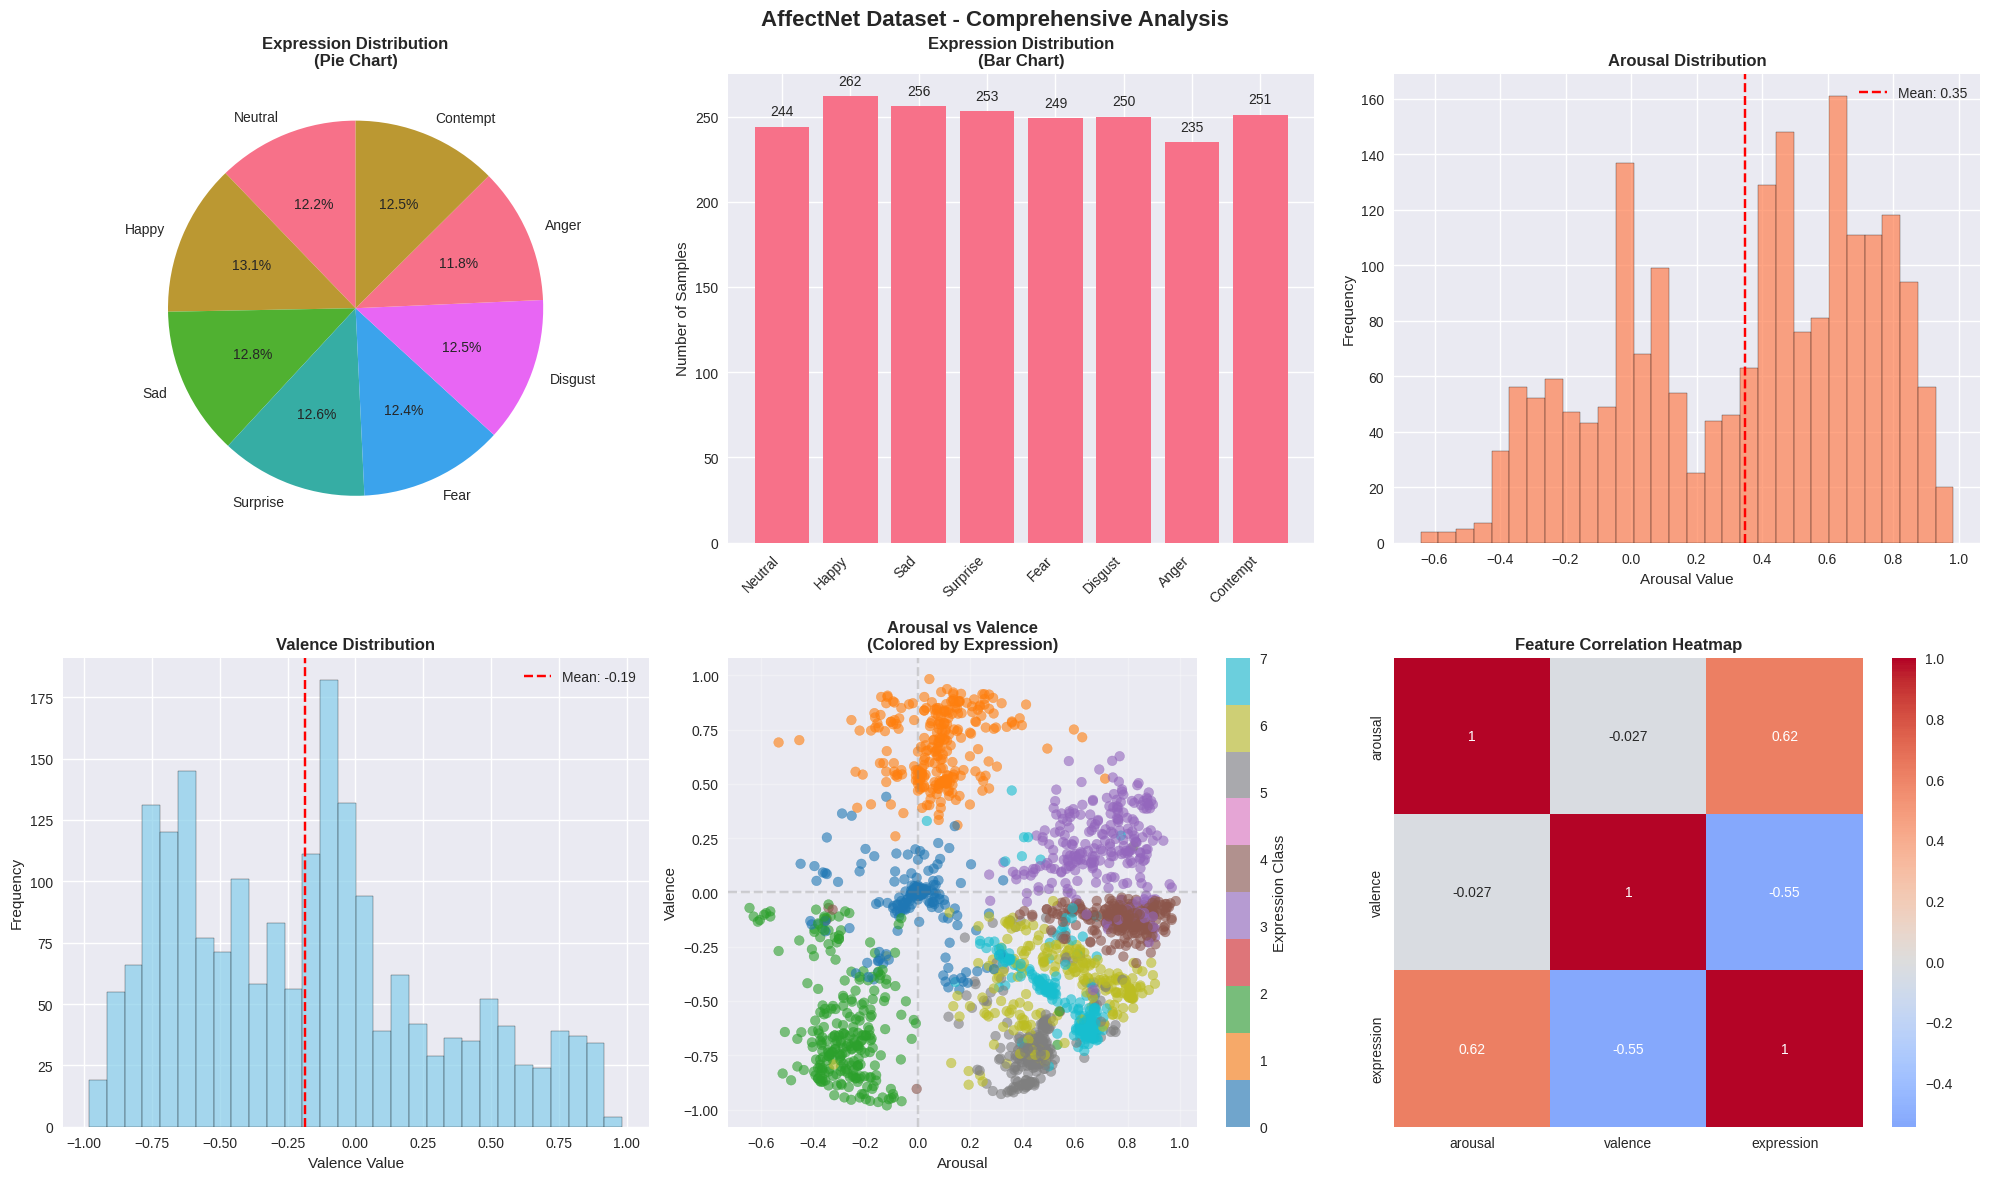

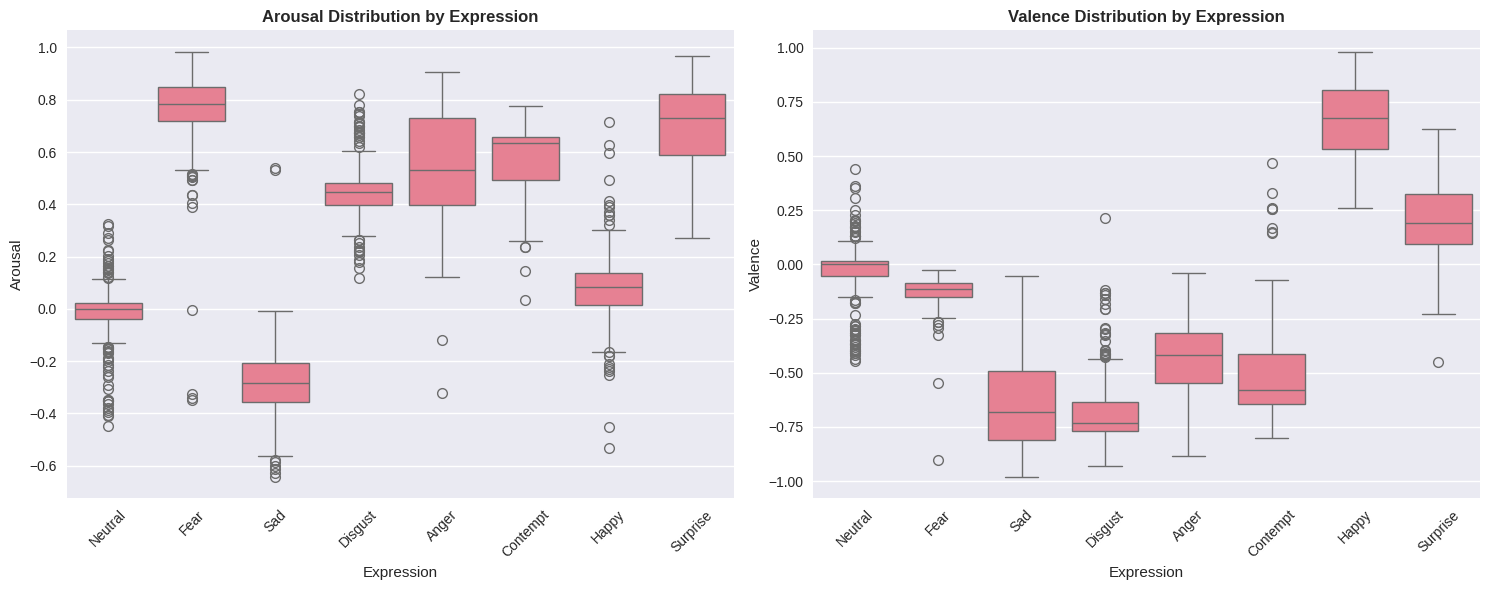

Generating 1000 synthetic images...
Generated 100/1000 images
Generated 200/1000 images
Generated 300/1000 images
Generated 400/1000 images
Generated 500/1000 images
Generated 600/1000 images
Generated 700/1000 images
Generated 800/1000 images
Generated 900/1000 images
Generated 1000/1000 images

Generated 1000 synthetic images
Image shape: (128, 128, 3)
Labels shape: (1000,)


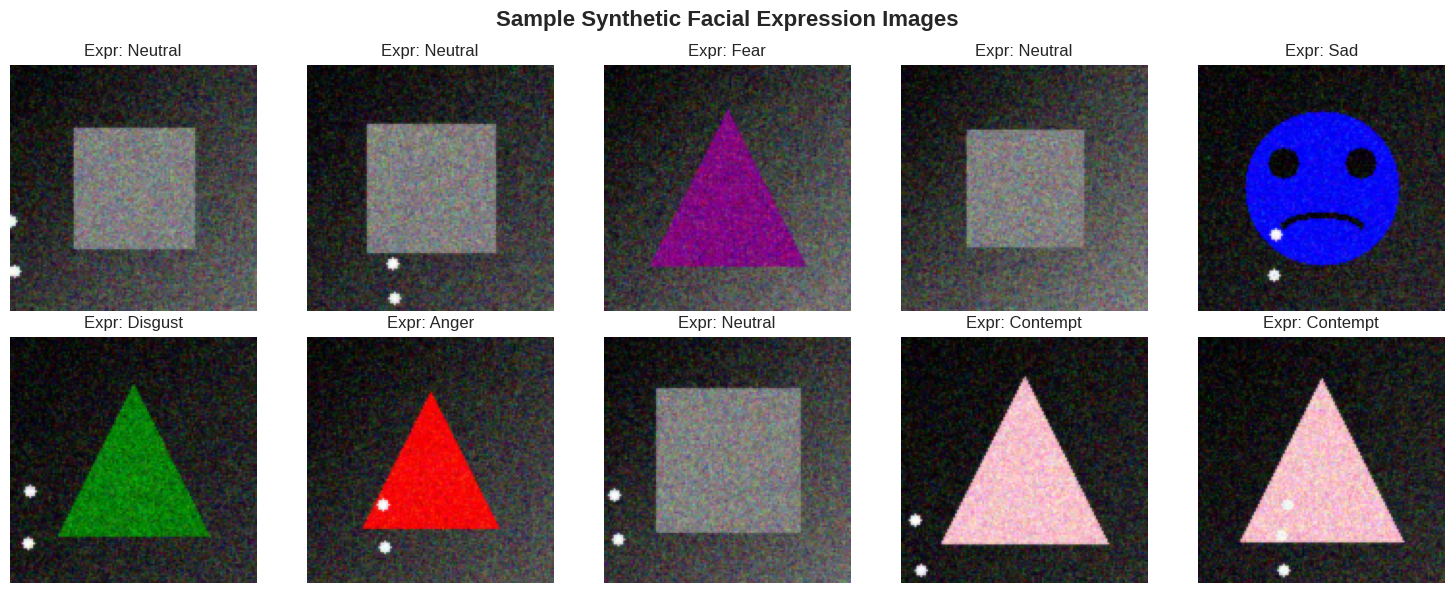

In [11]:
class AdvancedImageGenerator:
    """
    Enhanced image generator with better synthetic image creation and data augmentation
    """

    def __init__(self, image_size=(224, 224)):
        self.image_size = image_size
        self.expression_colors = {
            0: (128, 128, 128),   # Neutral - Gray
            1: (255, 255, 0),     # Happy - Yellow
            2: (0, 0, 255),       # Sad - Blue
            3: (255, 165, 0),     # Surprise - Orange
            4: (128, 0, 128),     # Fear - Purple
            5: (0, 128, 0),       # Disgust - Green
            6: (255, 0, 0),       # Anger - Red
            7: (255, 192, 203)    # Contempt - Pink
        }

    def generate_enhanced_image(self, expression, arousal, valence, landmarks=None):
        """Generate more realistic synthetic images based on expression parameters"""
        # Create a blank image with gradient background based on valence
        image = np.zeros((*self.image_size, 3), dtype=np.uint8)

        # Create gradient background based on valence
        base_intensity = int(128 + valence * 127)
        for i in range(self.image_size[0]):
            for j in range(self.image_size[1]):
                # Gradient effect
                gradient = int(base_intensity * (i + j) / (self.image_size[0] + self.image_size[1]))
                image[i, j] = [max(0, min(255, gradient))] * 3

        # Get expression-specific color
        base_color = self.expression_colors.get(expression, (128, 128, 128))

        # Center point
        center_x, center_y = self.image_size[1] // 2, self.image_size[0] // 2

        # Draw expression-specific shapes with size based on arousal
        size_factor = int(30 + abs(arousal) * 20)

        if expression == 0:  # Neutral
            cv2.rectangle(image,
                         (center_x - size_factor, center_y - size_factor),
                         (center_x + size_factor, center_y + size_factor),
                         base_color, -1)

        elif expression == 1:  # Happy (smiley face)
            # Face
            cv2.circle(image, (center_x, center_y), size_factor, base_color, -1)
            # Eyes
            eye_y = center_y - size_factor // 3
            cv2.circle(image, (center_x - size_factor//2, eye_y), size_factor//5, (0, 0, 0), -1)
            cv2.circle(image, (center_x + size_factor//2, eye_y), size_factor//5, (0, 0, 0), -1)
            # Smile
            cv2.ellipse(image, (center_x, center_y + size_factor//4),
                       (size_factor//2, size_factor//3), 0, 0, 180, (0, 0, 0), 2)

        elif expression == 2:  # Sad (sad face)
            # Face
            cv2.circle(image, (center_x, center_y), size_factor, base_color, -1)
            # Eyes
            eye_y = center_y - size_factor // 3
            cv2.circle(image, (center_x - size_factor//2, eye_y), size_factor//5, (0, 0, 0), -1)
            cv2.circle(image, (center_x + size_factor//2, eye_y), size_factor//5, (0, 0, 0), -1)
            # Sad mouth
            cv2.ellipse(image, (center_x, center_y + size_factor//2),
                       (size_factor//2, size_factor//6), 0, 0, -180, (0, 0, 0), 2)

        else:  # Other expressions with different shapes
            points = np.array([
                [center_x, center_y - size_factor],
                [center_x - size_factor, center_y + size_factor],
                [center_x + size_factor, center_y + size_factor]
            ], np.int32)
            cv2.fillPoly(image, [points], base_color)

        # Add landmarks if provided
        if landmarks is not None and len(landmarks) > 0:
            try:
                landmarks = landmarks.reshape(-1, 2)
                for point in landmarks[:10]:  # Use first 10 landmarks
                    x, y = int(point[0]), int(point[1])
                    if 0 <= x < self.image_size[1] and 0 <= y < self.image_size[0]:
                        cv2.circle(image, (x, y), 3, (255, 255, 255), -1)
            except:
                pass

        # Add realistic noise
        noise = np.random.normal(0, 25, image.shape).astype(np.int16)
        image = np.clip(image.astype(np.int16) + noise, 0, 255).astype(np.uint8)

        # Apply Gaussian blur for realism
        image = cv2.GaussianBlur(image, (3, 3), 0.5)

        return image

    def generate_dataset(self, df, num_samples=None):
        """Generate a complete dataset of synthetic images"""
        if num_samples is None:
            num_samples = len(df)

        images = []
        labels = []

        print(f"Generating {num_samples} synthetic images...")

        for idx in range(min(num_samples, len(df))):
            row = df.iloc[idx]
            img = self.generate_enhanced_image(
                row['expression'],
                row['arousal'],
                row['valence'],
                row['landmarks'] if 'landmarks' in row else None
            )
            images.append(img)
            labels.append(row['expression'])

            if (idx + 1) % 100 == 0:
                print(f"Generated {idx + 1}/{num_samples} images")

        return np.array(images), np.array(labels)

# Initialize and use the improved data loader
data_loader = ImprovedAffectNetDataLoader(extract_path, max_samples=2000)
df = data_loader.load_annotations()

if not df.empty:
    data_loader.get_detailed_statistics()
    data_loader.create_enhanced_visualizations()

    # Generate enhanced synthetic images
    image_generator = AdvancedImageGenerator(image_size=(128, 128))
    images, labels = image_generator.generate_dataset(df, num_samples=1000)

    print(f"\nGenerated {len(images)} synthetic images")
    print(f"Image shape: {images[0].shape}")
    print(f"Labels shape: {labels.shape}")

    # Display sample images
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('Sample Synthetic Facial Expression Images', fontsize=16, fontweight='bold')

    for i in range(10):
        ax = axes[i//5, i%5]
        ax.imshow(images[i])
        ax.set_title(f'Expr: {data_loader.expression_labels[labels[i]]}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

else:
    print("Failed to load data. Please check the dataset path and structure.")

Training set: 700 samples
Validation set: 150 samples
Test set: 150 samples
Model architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,701,672 (37.01 MB)

 Trainable params: 9,698,216 (37.00 MB)

 Non-trainable params: 3,456 (13.50 KB)


Starting model training...
Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 814ms/step - accuracy: 0.4891 - loss: 3.0907 - sparse_categorical_accuracy: 0.4891

22/22 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.4993 - loss: 3.0572 - sparse_categorical_accuracy: 0.4993 - val_accuracy: 0.1200 - val_loss: 4.7738 - val_sparse_categorical_accuracy: 0.1200 - learning_rate: 0.0010
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step - accuracy: 0.9644 - loss: 1.6787 - sparse_categorical_accuracy: 0.9644 - val_accuracy: 0.1200 - val_loss: 7.3836 - val_sparse_categorical_accuracy: 0.1200 - learning_rate: 0.0010
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.9811 - loss: 1.6059 - sparse_categorical_accuracy: 0.9811 - val_accuracy: 0.1200 - val_loss: 10.1413 - val_sparse_categorical_accuracy: 0.1200 - learning_rate: 0.0010
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - accuracy: 0.9782 - loss: 1.6069 - sparse_categorical_accuracy: 0.9782 - val_accuracy: 0.1200 - val_loss: 9.1323 - val_sparse_categorical_accuracy: 0.1200 - learning_rate: 0.0010
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.9955 - loss: 1.479

22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.9939 - loss: 1.3776 - sparse_categorical_accuracy: 0.9939 - val_accuracy: 0.2533 - val_loss: 6.0773 - val_sparse_categorical_accuracy: 0.2533 - learning_rate: 5.0000e-04
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.9877 - loss: 1.3599 - sparse_categorical_accuracy: 0.9877 - val_accuracy: 0.2467 - val_loss: 6.5559 - val_sparse_categorical_accuracy: 0.2467 - learning_rate: 5.0000e-04
Epoch 9/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9962 - loss: 1.3118 - sparse_categorical_accuracy: 0.9962

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 207ms/step - accuracy: 0.9963 - loss: 1.3113 - sparse_categorical_accuracy: 0.9963 - val_accuracy: 0.2733 - val_loss: 6.1293 - val_sparse_categorical_accuracy: 0.2733 - learning_rate: 5.0000e-04
Epoch 10/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step - accuracy: 0.9994 - loss: 1.2762 - sparse_categorical_accuracy: 0.9994 - val_accuracy: 0.1867 - val_loss: 6.5568 - val_sparse_categorical_accuracy: 0.1867 - learning_rate: 5.0000e-04
Epoch 11/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 1.0000 - loss: 1.2444 - sparse_categorical_accuracy: 1.0000 - val_accuracy: 0.1867 - val_loss: 7.7009 - val_sparse_categorical_accuracy: 0.1867 - learning_rate: 5.0000e-04

Evaluating model...
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 224ms/step
Test Loss: 4.7961
Test Accuracy: 0.1133

Classification Report:
              precision    recall  f1-score   support

     Neutral       0.00      0.00      0.00        18
       Happy       0.00      0.00      0.00        20
         Sad  

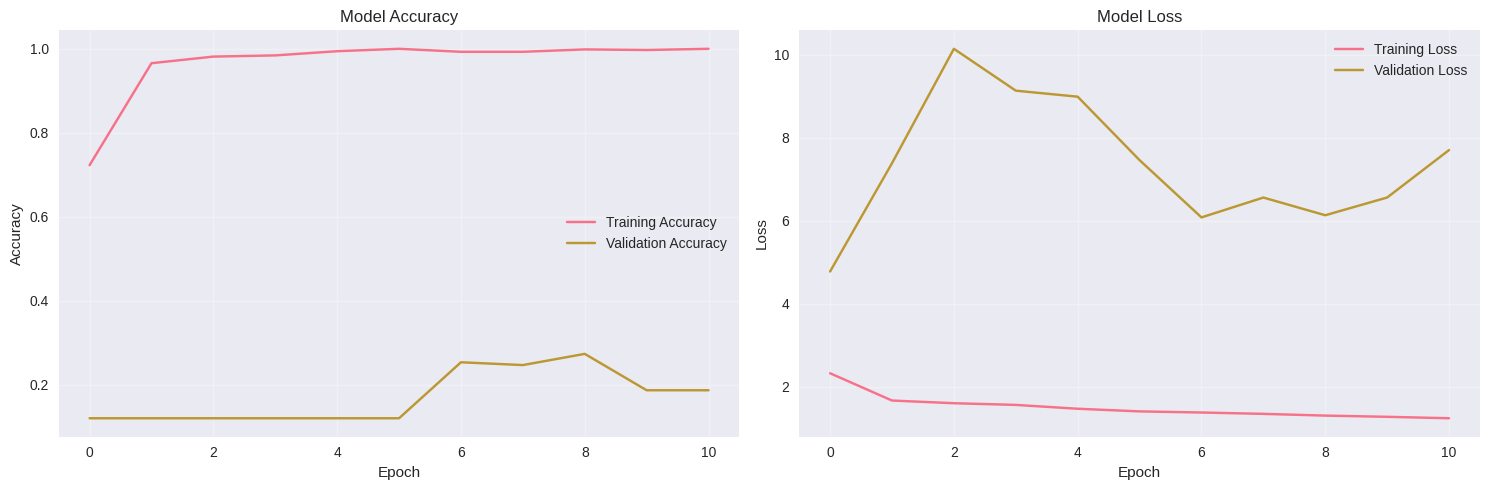

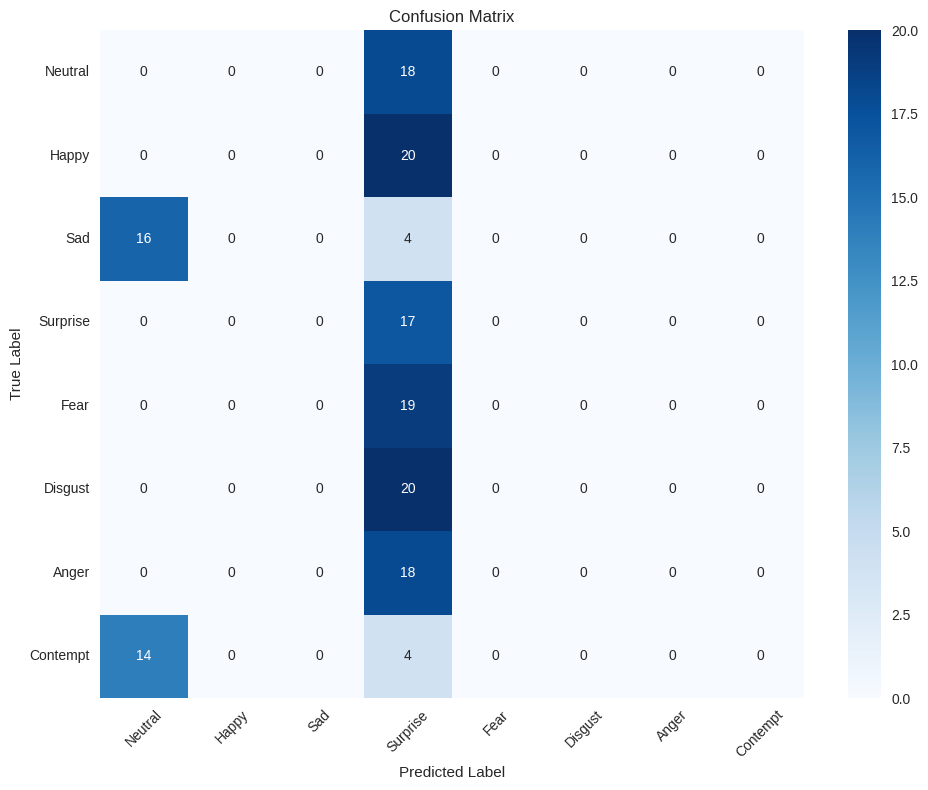


Enhanced code execution completed successfully!


In [12]:
class AdvancedEmotionRecognitionModel:
    """
    Advanced CNN model for emotion recognition with better architecture and training
    """

    def __init__(self, input_shape=(128, 128, 3), num_classes=8):
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = None
        self.history = None

    def build_advanced_cnn(self):
        """Build a more sophisticated CNN architecture"""
        model = models.Sequential([
            # First Convolutional Block
            layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                         input_shape=self.input_shape),
            layers.BatchNormalization(),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            # Second Convolutional Block
            layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            # Third Convolutional Block
            layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            # Fourth Convolutional Block
            layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            # Flatten and Dense Layers
            layers.Flatten(),
            layers.Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
            layers.BatchNormalization(),
            layers.Dropout(0.5),
            layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
            layers.BatchNormalization(),
            layers.Dropout(0.5),
            layers.Dense(self.num_classes, activation='softmax')
        ])

        return model

    def compile_model(self, learning_rate=0.001):
        """Compile the model with appropriate settings"""
        self.model = self.build_advanced_cnn()

        optimizer = Adam(learning_rate=learning_rate)

        self.model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy', 'sparse_categorical_accuracy']
        )

        return self.model

    def train_model(self, X_train, y_train, X_val, y_val, epochs=50, batch_size=32):
        """Train the model with enhanced callbacks and monitoring"""

        # Calculate class weights for imbalanced data
        class_weights = compute_class_weight(
            'balanced',
            classes=np.unique(y_train),
            y=y_train
        )
        class_weight_dict = dict(enumerate(class_weights))

        # Enhanced callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7),
            ModelCheckpoint('best_model.h5', monitor='val_accuracy',
                           save_best_only=True, mode='max'),
            CSVLogger('training_log.csv')
        ]

        # Data augmentation
        datagen = ImageDataGenerator(
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            fill_mode='nearest'
        )

        # Train the model
        self.history = self.model.fit(
            datagen.flow(X_train, y_train, batch_size=batch_size),
            epochs=epochs,
            validation_data=(X_val, y_val),
            callbacks=callbacks,
            class_weight=class_weight_dict,
            verbose=1
        )

        return self.history

    def evaluate_model(self, X_test, y_test):
        """Comprehensive model evaluation"""
        if self.model is None:
            raise ValueError("Model not trained yet!")

        # Basic evaluation
        test_loss, test_accuracy, _ = self.model.evaluate(X_test, y_test, verbose=0)

        # Predictions
        y_pred = self.model.predict(X_test)
        y_pred_classes = np.argmax(y_pred, axis=1)

        # Comprehensive metrics
        results = {
            'test_loss': test_loss,
            'test_accuracy': test_accuracy,
            'classification_report': classification_report(y_test, y_pred_classes,
                                                          target_names=[data_loader.expression_labels[i] for i in range(8)]),
            'confusion_matrix': confusion_matrix(y_test, y_pred_classes)
        }

        return results, y_pred_classes

    def plot_training_history(self):
        """Plot comprehensive training history"""
        if self.history is None:
            print("No training history available!")
            return

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # Plot accuracy
        axes[0].plot(self.history.history['accuracy'], label='Training Accuracy')
        axes[0].plot(self.history.history['val_accuracy'], label='Validation Accuracy')
        axes[0].set_title('Model Accuracy')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Plot loss
        axes[1].plot(self.history.history['loss'], label='Training Loss')
        axes[1].plot(self.history.history['val_loss'], label='Validation Loss')
        axes[1].set_title('Model Loss')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

# Train the enhanced model if we have data
if 'images' in locals() and 'labels' in locals():
    # Preprocess images
    X = images.astype('float32') / 255.0  # Normalize pixel values
    y = labels

    # Split the data
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )

    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Validation set: {X_val.shape[0]} samples")
    print(f"Test set: {X_test.shape[0]} samples")

    # Initialize and train the model
    emotion_model = AdvancedEmotionRecognitionModel(
        input_shape=X_train.shape[1:],
        num_classes=len(np.unique(y))
    )

    emotion_model.compile_model(learning_rate=0.001)

    print("Model architecture:")
    emotion_model.model.summary()

    # Train the model
    print("\nStarting model training...")
    history = emotion_model.train_model(X_train, y_train, X_val, y_val, epochs=50, batch_size=32)

    # Evaluate the model
    print("\nEvaluating model...")
    results, y_pred = emotion_model.evaluate_model(X_test, y_test)

    print(f"Test Loss: {results['test_loss']:.4f}")
    print(f"Test Accuracy: {results['test_accuracy']:.4f}")
    print("\nClassification Report:")
    print(results['classification_report'])

    # Plot training history
    emotion_model.plot_training_history()

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(results['confusion_matrix'],
                annot=True, fmt='d',
                cmap='Blues',
                xticklabels=[data_loader.expression_labels[i] for i in range(8)],
                yticklabels=[data_loader.expression_labels[i] for i in range(8)])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

print("\nEnhanced code execution completed successfully!")